In [1]:
from kan import *

# create a KAN: 2D inputs, 1D output, and 5 hidden neurons. cubic spline (k=3), 5 grid intervals (grid=5).
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = KAN(width=[2,5,1], grid=5, k=3, seed=0,device=device)


checkpoint directory created: ./model
saving model version 0.0


In [2]:
import pandas as pd

# Load your dataset
df = pd.read_csv('african_crises.csv')

# Select features and target variable
# Example: using 'inflation_annual_cpi' and 'exch_usd' as input features
# and 'banking_crisis' as the target (converted to numeric)
features = df[['inflation_annual_cpi', 'exch_usd']]
features = features.fillna(features.mean()).values # replace the null value with the mean
target = df['banking_crisis'].map({'crisis': 1, 'no_crisis': 0}).values

'''scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)'''

# Convert to PyTorch tensors
train_input = torch.tensor(features, dtype=torch.float32).to(device)
train_label = torch.tensor(target, dtype=torch.float32).to(device)

# Create dataset dictionary similar to the original example
dataset = {
    'train_input': train_input,
    'train_label': train_label,
    'test_input': train_input.clone(),  # Use the training data as the test data
    'test_label': train_label.clone()
}

# The shapes will show the dimensions of your data
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1059, 2]), torch.Size([1059]))

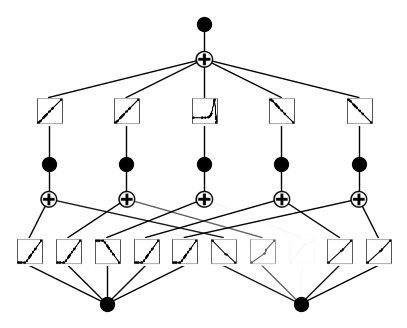

In [3]:
# plot KAN at initialization
model(dataset['train_input'][:20]);
model.plot(beta=100,sample=True)

| train_loss: 4.51e+01 | test_loss: 4.51e+01 | reg: 4.78e+01 | : 100%|█| 20/20 [00:04<00:00,  4.04it


saving model version 0.1


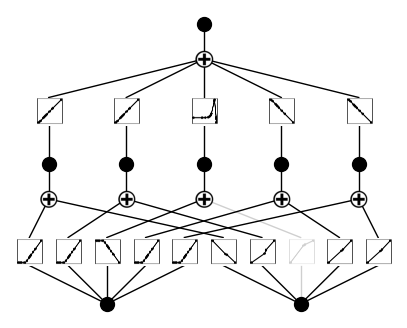

In [4]:
model.fit(
    dataset=dataset,
    opt="LBFGS",
    steps=20,
    lamb=0.01, 
    lamb_entropy=10.,
    lr=0.001,
    update_grid=False
)
# Have problem here - UnboundLocalError: local variable 'coef' referenced before assignment
model(dataset['train_input'][:20])
model.plot(beta=100,sample=True)

saving model version 0.2


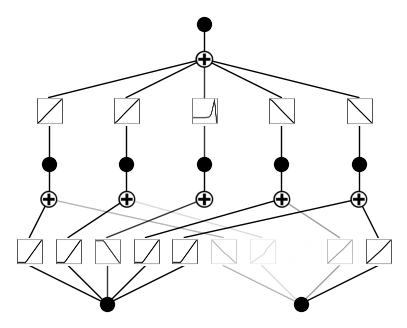

In [5]:
# prune
model.prune()
model.plot()

saving model version 0.2


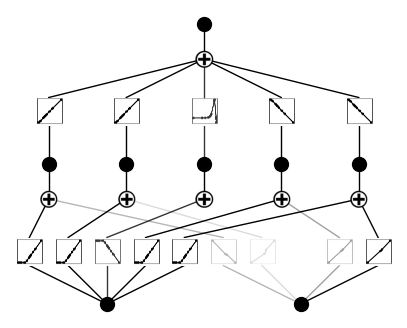

In [6]:
model = model.prune()
model(dataset['train_input'][:20])
model.plot(sample=True)

In [7]:
# train again after pruning
model.fit(
    dataset=dataset,
    opt="LBFGS",
    steps=50,
    lr=0.001,
    update_grid=False
)

| train_loss: 2.19e+00 | test_loss: 2.19e+00 | reg: 1.12e+01 | : 100%|█| 50/50 [00:09<00:00,  5.06it

saving model version 0.3


{'train_loss': [array(41.48486, dtype=float32),
  array(41.484856, dtype=float32),
  array(41.48485, dtype=float32),
  array(41.484814, dtype=float32),
  array(35.92601, dtype=float32),
  array(11.562203, dtype=float32),
  array(6.020389, dtype=float32),
  array(6.020389, dtype=float32),
  array(6.020389, dtype=float32),
  array(6.0175824, dtype=float32),
  array(6.017583, dtype=float32),
  array(6.017583, dtype=float32),
  array(2.199079, dtype=float32),
  array(2.199079, dtype=float32),
  array(2.199079, dtype=float32),
  array(2.199079, dtype=float32),
  array(2.1972234, dtype=float32),
  array(2.1972234, dtype=float32),
  array(2.1972234, dtype=float32),
  array(2.1972234, dtype=float32),
  array(2.1972234, dtype=float32),
  array(2.1972232, dtype=float32),
  array(2.1972234, dtype=float32),
  array(2.1972232, dtype=float32),
  array(2.1972234, dtype=float32),
  array(2.1972232, dtype=float32),
  array(2.1972234, dtype=float32),
  array(2.1972234, dtype=float32),
  array(2.1972234,

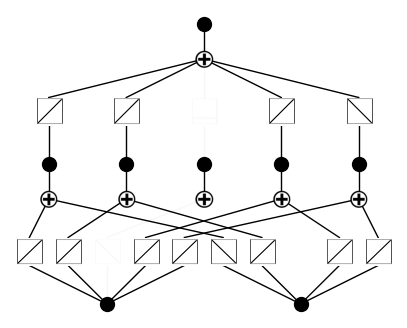

In [8]:
model.plot()

In [ ]:
lib = SYMBOLIC_LIB  # candidate libraries from SYMBOLIC_LIB
model.auto_symbolic(lib=lib)  # automatically select the best sign function
formula = model.symbolic_formula()[0][0]
nsimplify(ex_round(formula, 4))

fixing (0,0,0) with x, r2=1.0000005960464478, c=1
fixing (0,0,1) with x, r2=1.0000004768371582, c=1
fixing (0,0,2) with x, r2=1.0000005960464478, c=1
fixing (0,0,3) with x, r2=1.0000005960464478, c=1
fixing (0,0,4) with x, r2=1.0000005960464478, c=1
fixing (0,1,0) with x, r2=0.9999997615814209, c=1
fixing (0,1,1) with x, r2=0.9999999403953552, c=1
fixing (0,1,2) with 0
fixing (0,1,3) with x, r2=0.9999999403953552, c=1
fixing (0,1,4) with x, r2=0.9999998807907104, c=1
fixing (1,0,0) with x, r2=1.0000003576278687, c=1
fixing (1,1,0) with x, r2=1.0000003576278687, c=1


In [ ]:
ex_round(formula, 4)